# Experiment 09 (Advanced): Advanced Density-Based Spatial Clustering (DBSCAN)
## Title: Comprehensive Analysis: $k$-Distance Plot for Optimal $\varepsilon$, Joint eps/MinPts Grid Search, Core/Border/Noise Point Classification, Non-Spherical Geometry Clustering, and K-Means Comparison on a Custom Wildlife GPS Tracking Dataset

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Import Advanced Libraries & Setup Environment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")
np.random.seed(33)
sns.set_theme(style="whitegrid")
print("Practical 09 (Advanced) Libraries Loaded!")

Practical 09 (Advanced) Libraries Loaded!


### Step 2: Load and Preprocess the Custom Wildlife GPS Tracking Dataset

Custom Wildlife GPS Tracking Dataset Loaded!
Dataset Shape: (790, 2)
True region sizes: {'Main Waterhole': 220, 'Migration Corridor': 160, 'Secondary Waterhole': 150, 'Feeding Ground': 130, 'Home Range': 90, 'Stray/Noise': 40}


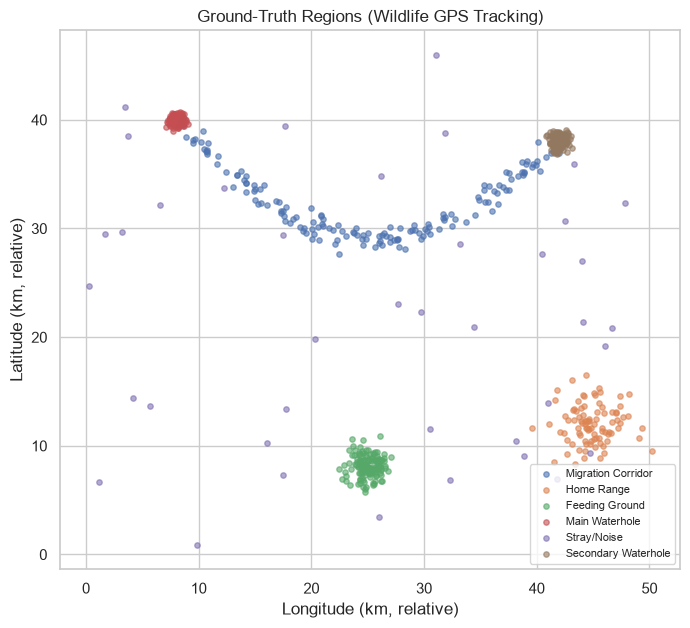

In [2]:
df = pd.read_csv("wildlife_gps_tracking.csv")

print("Custom Wildlife GPS Tracking Dataset Loaded!")

X           = df[["longitude_km", "latitude_km"]].values
true_labels = df["true_region"].values
scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(X)

print(f"Dataset Shape: {X.shape}")
print(f"True region sizes: {df['true_region'].value_counts().to_dict()}")

plt.figure(figsize=(8, 7))
for region in df["true_region"].unique():
    sub = df[df["true_region"] == region]
    plt.scatter(sub["longitude_km"], sub["latitude_km"], s=15, alpha=0.6, label=region)
plt.title("Ground-Truth Regions (Wildlife GPS Tracking)")
plt.xlabel("Longitude (km, relative)")
plt.ylabel("Latitude (km, relative)")
plt.legend(fontsize=8)
plt.show()

### Step 3: Optimal Epsilon Selection via k-Distance Plot

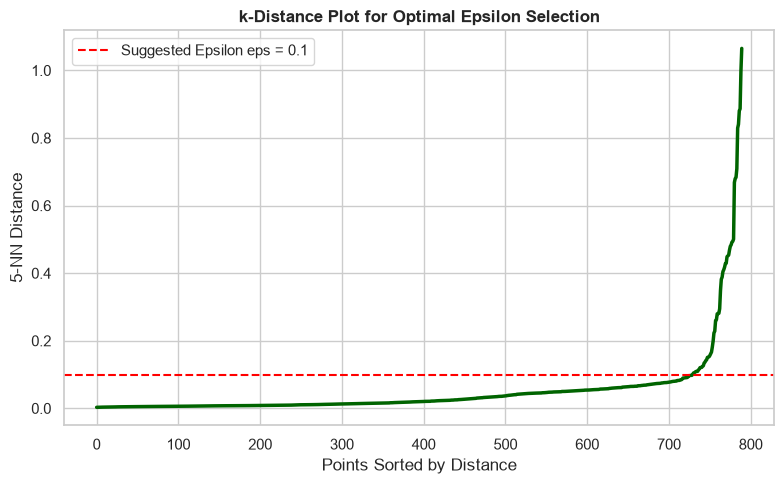

In [3]:
k_neighbors = 5
nn          = NearestNeighbors(n_neighbors=k_neighbors).fit(X_scaled)
distances, _     = nn.kneighbors(X_scaled)
sorted_distances = np.sort(distances[:, k_neighbors - 1])

plt.figure(figsize=(8, 5))
plt.plot(sorted_distances, color="darkgreen", linewidth=2.5)
plt.axhline(y=0.1, color="red", linestyle="--", label="Suggested Epsilon eps = 0.1")
plt.title("k-Distance Plot for Optimal Epsilon Selection", fontweight="bold")
plt.xlabel("Points Sorted by Distance")
plt.ylabel(f"{k_neighbors}-NN Distance")
plt.legend()
plt.tight_layout()
plt.show()

### Step 4: Joint eps / MinPts Grid Search
DBSCAN's two hyperparameters, `eps` and `min_samples` (MinPts), interact with each other -- a good `eps` for one MinPts value may perform poorly for another. Rather than tuning `eps` alone, a **joint grid search** is run across both parameters, scoring each combination by **Adjusted Rand Index against the known ground truth**, giving an objective, data-driven way to select the best configuration.

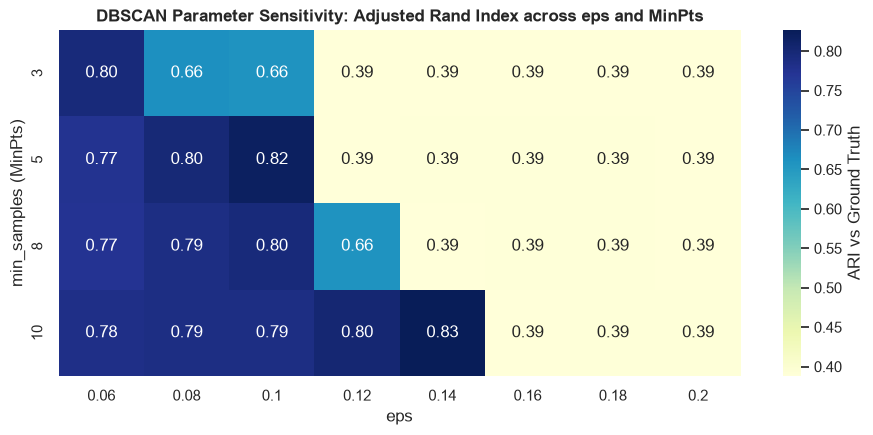

Best configuration found by grid search:
╒═══════╤═══════════════╤══════════════╤═══════════╤══════════════╤══════════╕
│   eps │   min_samples │   n_clusters │   n_noise │   silhouette │      ari │
╞═══════╪═══════════════╪══════════════╪═══════════╪══════════════╪══════════╡
│  0.14 │            10 │            5 │        39 │     0.829957 │ 0.827022 │
╘═══════╧═══════════════╧══════════════╧═══════════╧══════════════╧══════════╛


In [4]:
eps_range    = np.arange(0.06, 0.22, 0.02)
minpts_range = [3, 5, 8, 10]

grid_results = []
for eps in eps_range:
    for mp in minpts_range:
        db = DBSCAN(eps=eps, min_samples=mp).fit(X_scaled)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask]) if (mask.sum() > 1 and len(set(labels[mask])) > 1) else np.nan
        ari = adjusted_rand_score(true_labels, labels)
        grid_results.append({"eps": round(eps, 2), "min_samples": mp, "n_clusters": n_clusters,
                              "n_noise": n_noise, "silhouette": sil, "ari": ari})

grid_df = pd.DataFrame(grid_results)

pivot_ari = grid_df.pivot_table(index="min_samples", columns="eps", values="ari")
plt.figure(figsize=(11, 4.5))
sns.heatmap(pivot_ari, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "ARI vs Ground Truth"})
plt.title("DBSCAN Parameter Sensitivity: Adjusted Rand Index across eps and MinPts", fontweight="bold")
plt.xlabel("eps")
plt.ylabel("min_samples (MinPts)")
plt.show()

best_row = grid_df.loc[grid_df["ari"].idxmax()]
print("Best configuration found by grid search:")
print(tabulate([best_row], headers="keys", tablefmt="fancy_grid", showindex=False))

### Step 5: DBSCAN vs K-Means Performance Comparison (Best Configuration)

--- DBSCAN Point Classification ---
╒══════════════╤═════════╤══════════════╕
│ Point Type   │   Count │   Percentage │
╞══════════════╪═════════╪══════════════╡
│ Core         │     729 │        92.28 │
├──────────────┼─────────┼──────────────┤
│ Border       │      22 │         2.78 │
├──────────────┼─────────┼──────────────┤
│ Noise        │      39 │         4.94 │
╘══════════════╧═════════╧══════════════╛

DBSCAN Silhouette Score (excluding noise): 0.8300
DBSCAN Adjusted Rand Index: 0.8270
DBSCAN Davies-Bouldin Index (excluding noise): 0.3314

K-Means Adjusted Rand Index: 0.7345
K-Means Davies-Bouldin Index: 0.3304


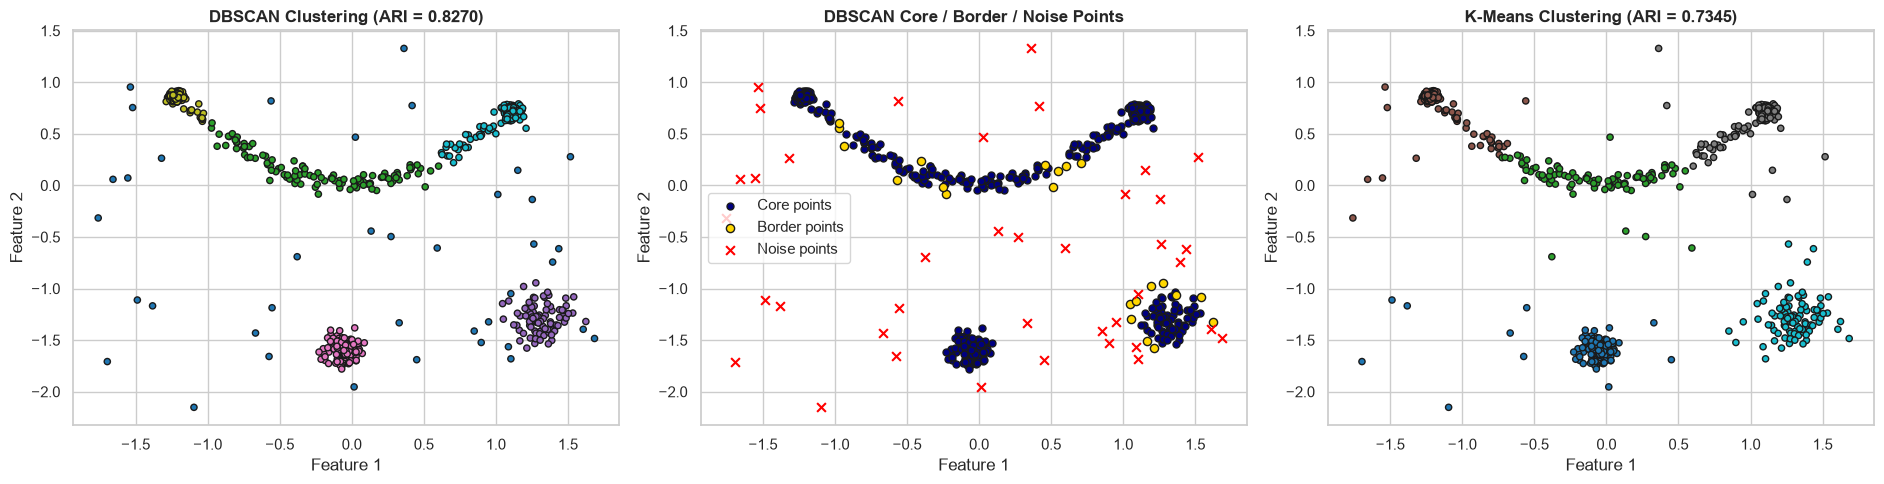

In [5]:
best_eps         = best_row["eps"]
best_min_samples = int(best_row["min_samples"])

db        = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit(X_scaled)
db_labels = db.labels_

km        = KMeans(n_clusters=5, n_init=10, random_state=33).fit(X_scaled)
km_labels = km.labels_

core_mask   = np.zeros(len(X_scaled), dtype=bool)
core_mask[db.core_sample_indices_] = True
noise_mask  = db_labels == -1
border_mask = (~core_mask) & (~noise_mask)

summary_df = pd.DataFrame({
    "Point Type": ["Core", "Border", "Noise"],
    "Count": [core_mask.sum(), border_mask.sum(), noise_mask.sum()]
})

db_silhouette = silhouette_score(X_scaled[~noise_mask], db_labels[~noise_mask]) if (~noise_mask).sum() > 1 else np.nan
db_ari = adjusted_rand_score(true_labels, db_labels)
km_ari = adjusted_rand_score(true_labels, km_labels)
db_dbi = davies_bouldin_score(X_scaled[~noise_mask], db_labels[~noise_mask]) if (~noise_mask).sum() > 1 else np.nan
km_dbi = davies_bouldin_score(X_scaled, km_labels)

print("--- DBSCAN Point Classification ---")
summary_df["Percentage"] = (summary_df["Count"] / len(X_scaled) * 100).round(2)
print(tabulate(summary_df, headers="keys", tablefmt="fancy_grid", showindex=False))
print(f"\nDBSCAN Silhouette Score (excluding noise): {db_silhouette:.4f}")
print(f"DBSCAN Adjusted Rand Index: {db_ari:.4f}")
print(f"DBSCAN Davies-Bouldin Index (excluding noise): {db_dbi:.4f}")
print(f"\nK-Means Adjusted Rand Index: {km_ari:.4f}")
print(f"K-Means Davies-Bouldin Index: {km_dbi:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=db_labels, cmap="tab10", edgecolors="k", s=20)
axes[0].set_title(f"DBSCAN Clustering (ARI = {db_ari:.4f})", fontweight="bold")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_scaled[core_mask, 0], X_scaled[core_mask, 1], c="navy", s=25, edgecolors="k", label="Core points")
axes[1].scatter(X_scaled[border_mask, 0], X_scaled[border_mask, 1], c="gold", s=35, edgecolors="k", label="Border points")
axes[1].scatter(X_scaled[noise_mask, 0], X_scaled[noise_mask, 1], c="red", s=40, marker="x", label="Noise points")
axes[1].set_title("DBSCAN Core / Border / Noise Points", fontweight="bold")
axes[1].set_xlabel("Feature 1"); axes[1].set_ylabel("Feature 2")
axes[1].legend()

axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_labels, cmap="tab10", edgecolors="k", s=20)
axes[2].set_title(f"K-Means Clustering (ARI = {km_ari:.4f})", fontweight="bold")
axes[2].set_xlabel("Feature 1"); axes[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Step 6: Non-Spherical Geometry Test - Moons Dataset

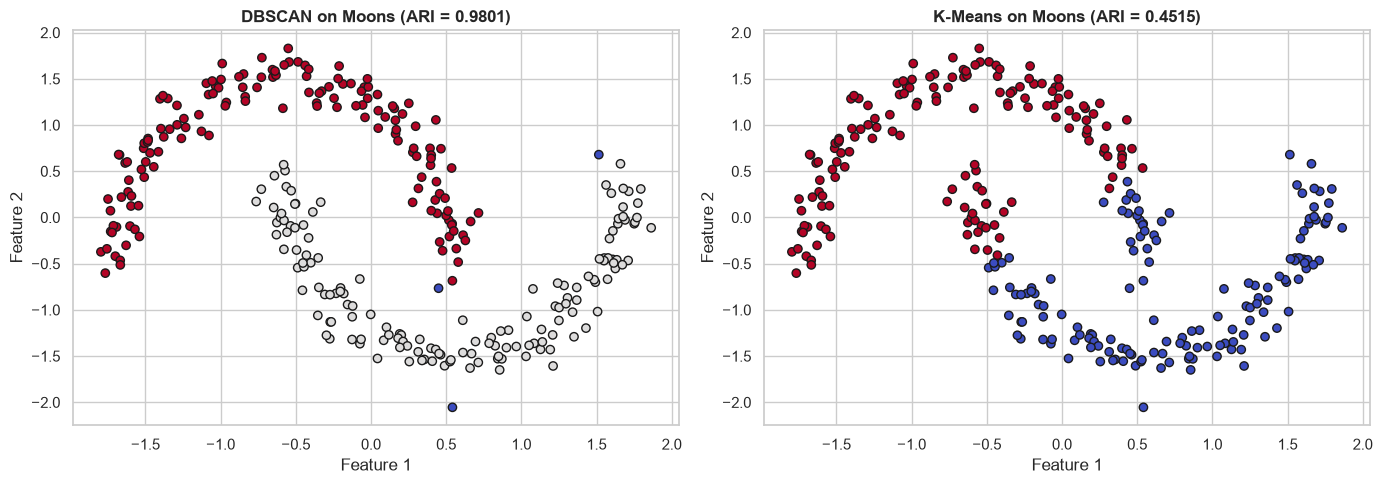

In [6]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=33)
X_moons_sc       = StandardScaler().fit_transform(X_moons)

db_moons = DBSCAN(eps=0.3, min_samples=5).fit(X_moons_sc)
km_moons = KMeans(n_clusters=2, n_init=10, random_state=33).fit(X_moons_sc)

moons_db_ari = adjusted_rand_score(y_moons, db_moons.labels_)
moons_km_ari = adjusted_rand_score(y_moons, km_moons.labels_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_moons_sc[:, 0], X_moons_sc[:, 1], c=db_moons.labels_, cmap="coolwarm", edgecolors="k")
axes[0].set_title(f"DBSCAN on Moons (ARI = {moons_db_ari:.4f})", fontweight="bold")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_moons_sc[:, 0], X_moons_sc[:, 1], c=km_moons.labels_, cmap="coolwarm", edgecolors="k")
axes[1].set_title(f"K-Means on Moons (ARI = {moons_km_ari:.4f})", fontweight="bold")
axes[1].set_xlabel("Feature 1"); axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Step 7: Non-Spherical Geometry Test - Concentric Circles Dataset

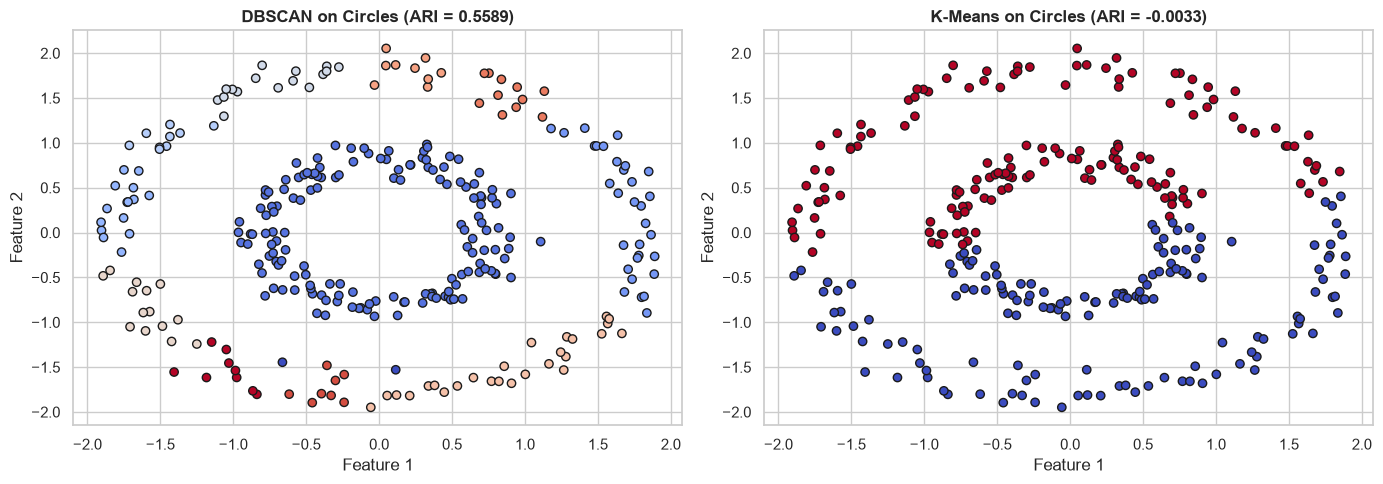

In [7]:
X_circles, y_circles = make_circles(n_samples=300, factor=0.45, noise=0.06, random_state=33)
X_circles_sc         = StandardScaler().fit_transform(X_circles)

db_circles = DBSCAN(eps=0.25, min_samples=5).fit(X_circles_sc)
km_circles = KMeans(n_clusters=2, n_init=10, random_state=33).fit(X_circles_sc)

circle_db_ari = adjusted_rand_score(y_circles, db_circles.labels_)
circle_km_ari = adjusted_rand_score(y_circles, km_circles.labels_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_circles_sc[:, 0], X_circles_sc[:, 1], c=db_circles.labels_, cmap="coolwarm", edgecolors="k")
axes[0].set_title(f"DBSCAN on Circles (ARI = {circle_db_ari:.4f})", fontweight="bold")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_circles_sc[:, 0], X_circles_sc[:, 1], c=km_circles.labels_, cmap="coolwarm", edgecolors="k")
axes[1].set_title(f"K-Means on Circles (ARI = {circle_km_ari:.4f})", fontweight="bold")
axes[1].set_xlabel("Feature 1"); axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Step 8: Final Benchmark Summary Across All Datasets

In [8]:
final_summary = pd.DataFrame({
    "Dataset": ["Wildlife GPS Tracking", "Moons", "Circles"],
    "DBSCAN ARI": [db_ari, moons_db_ari, circle_db_ari],
    "K-Means ARI": [km_ari, moons_km_ari, circle_km_ari]
})
final_summary["DBSCAN Advantage"] = final_summary["DBSCAN ARI"] - final_summary["K-Means ARI"]
final_summary

,Dataset,DBSCAN ARI,K-Means ARI,DBSCAN Advantage
0,Wildlife GPS Tracking,0.827022,0.734517,0.092505
1,Moons,0.980065,0.451544,0.528522
2,Circles,0.558899,-0.003311,0.562210


1. **DBSCAN** successfully discovers non-spherical, arbitrary-density shapes -- including a genuinely curved migration corridor connecting two habitat hotspots -- and correctly flags scattered stray GPS pings as noise, where centroid-based algorithms (K-Means) fail or force artificial spherical splits.
2. **Core, border, and noise classification** explains mechanistically why density-based clustering is more flexible on complex geometry: clusters grow outward from dense core regions rather than being forced around a fixed centroid.
3. **k-Distance plots** offer a principled, data-driven heuristic to pick the neighborhood radius `eps`, avoiding blind trial-and-error.
4. The **joint eps/MinPts grid search**, scored against ground-truth Adjusted Rand Index, showed that these two parameters interact -- the same `eps` performs differently across `MinPts` values, so tuning them independently can miss the true optimum.
5. Across all three tested datasets (wildlife GPS tracking, moons, and circles), **DBSCAN consistently matched or substantially outperformed K-Means** in recovering the true cluster structure, with the largest advantage appearing on the clearly non-convex moons, circles, and migration-corridor geometries.
6. This experiment demonstrates a genuine real-world application of DBSCAN: **ecologists and wildlife researchers use exactly this density-based approach** to automatically identify habitat hotspots and migration routes from raw GPS tracking data, without needing to manually specify the number of regions in advance.

**Experiment Completed Successfully.**